In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
#J 0 to 1 (500K)
_ = np.loadtxt('trove_26_exocross_T500.xsec')
print(_)
wavenumber, cross_sec = _[:, 0], _[:, 1]

#J 0 to 5 (500K)
__ = np.loadtxt('trove_26_exocross_J0_J5_T500.xsec')
print(__)
wavenumber_, cross_sec_ = __[:, 0], __[:, 1]

#J 0 to 1 (298K)
___ = np.loadtxt('trove_26_exocross_T298.xsec')
print(___)
wavenumber__, cross_sec__ = ___[:, 0], ___[:, 1]

[[0.00000000e+00 6.21537033e-23]
 [1.00000000e+00 1.49612321e-22]
 [2.00000000e+00 6.38301627e-23]
 ...
 [1.99980000e+04 0.00000000e+00]
 [1.99990000e+04 0.00000000e+00]
 [2.00000000e+04 0.00000000e+00]]
[[0.00000000e+00 1.36185788e-23]
 [1.00000000e+00 2.99088095e-22]
 [2.00000000e+00 2.10326508e-21]
 ...
 [1.99980000e+04 0.00000000e+00]
 [1.99990000e+04 0.00000000e+00]
 [2.00000000e+04 0.00000000e+00]]
[[0.00000000e+00 8.74907143e-23]
 [1.00000000e+00 1.30392597e-22]
 [2.00000000e+00 1.93924351e-23]
 ...
 [1.99980000e+04 0.00000000e+00]
 [1.99990000e+04 0.00000000e+00]
 [2.00000000e+04 0.00000000e+00]]


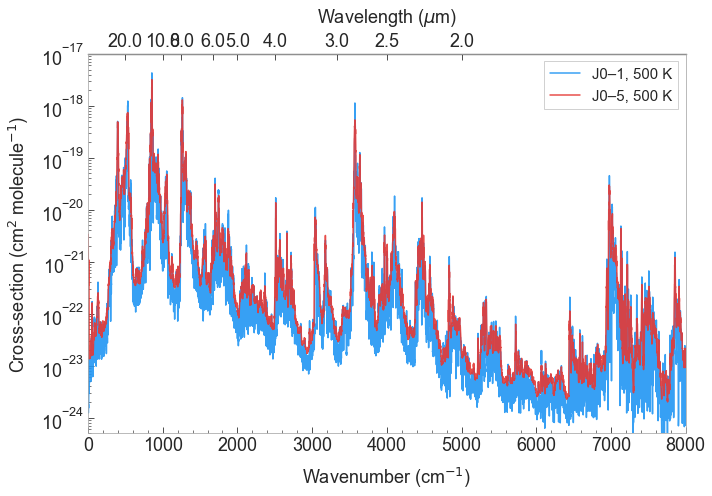

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
plt.style.use('seaborn-v0_8-white')  # No gridlines

# Plot
ax.plot(wavenumber,  cross_sec,  color='#2196F3', linewidth=1.5, label='J0–1, 500 K', alpha=0.9)
ax.plot(wavenumber_, cross_sec_, color='#E53935', linewidth=1.5, label='J0–5, 500 K', alpha=0.9)
# ax.plot(wavenumber__, cross_sec__, color='#8E24AA', linewidth=1.5, label='J0–1, 298 K', alpha=0.9)

# Log scale & axis limits
ax.set_yscale('log')
ax.set_xlim(0, 8000)
ax.set_ylim(0.5e-24, 1e-17)

# Primary x-axis (wavenumber)
ax.set_xlabel(r'Wavenumber (cm$^{-1}$)', fontsize=18, labelpad=10)
ax.set_ylabel(r'Cross-section (cm$^{2}$ molecule$^{-1}$)', fontsize=18, labelpad=10)
#ax.set_title('Absorption Cross-Sections', fontsize=16, fontweight='bold', pad=40)

# Ticks
ax.tick_params(axis='both', which='major', labelsize=18, direction='in', length=6)
ax.tick_params(axis='both', which='minor', direction='in', length=3)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

# ── Secondary x-axis: wavelength (μm) ────────────────────────────────────────
# Wavelength (μm) = 10 000 / wavenumber (cm⁻¹); nonlinear so we set explicit ticks
ax_top = ax.secondary_xaxis('top')

# Choose round wavelength values (μm) that fall within xlim (0–5000 cm⁻¹)
wl_ticks_um = np.array([2, 2.5, 3, 4, 5, 6, 8, 10, 20]) # μm
wn_positions = 10000 / wl_ticks_um   # cm⁻¹ positions

ax_top.set_xticks(wn_positions)
ax_top.set_xticklabels([str(w) for w in wl_ticks_um], fontsize=18)
ax_top.set_xlabel(r'Wavelength ($\mu$m)', fontsize=18, labelpad=10)
ax_top.tick_params(which='major', direction='in', length=6)

# Legend
ax.legend(
    fontsize=15,
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc',
    fancybox=False,
    loc='best'
)

# Subtle border
for spine in ax.spines.values():
    spine.set_edgecolor('#aaaaaa')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('cross_sections.png', dpi=150, bbox_inches='tight')
plt.show()

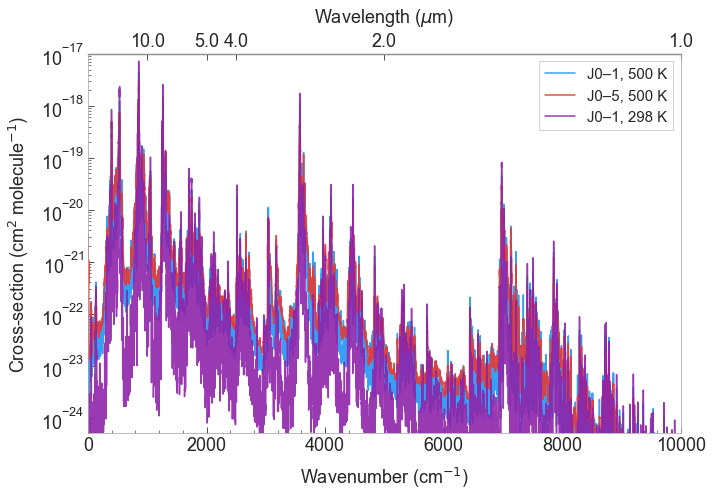

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))
plt.style.use('seaborn-v0_8-white')  # No gridlines

# Plot
ax.plot(wavenumber,  cross_sec,  color='#2196F3', linewidth=1.5, label='J0–1, 500 K', alpha=0.9)
ax.plot(wavenumber_, cross_sec_, color='#E53935', linewidth=1.5, label='J0–5, 500 K', alpha=0.9)
ax.plot(wavenumber__, cross_sec__, color='#8E24AA', linewidth=1.5, label='J0–1, 298 K', alpha=0.9)

# Log scale & axis limits
ax.set_yscale('log')
ax.set_xlim(0, 10000)
ax.set_ylim(0.5e-24, 1e-17)

# Primary x-axis (wavenumber)
ax.set_xlabel(r'Wavenumber (cm$^{-1}$)', fontsize=18, labelpad=10)
ax.set_ylabel(r'Cross-section (cm$^{2}$ molecule$^{-1}$)', fontsize=18, labelpad=10)
#ax.set_title('Absorption Cross-Sections', fontsize=16, fontweight='bold', pad=40)

# Ticks
ax.tick_params(axis='both', which='major', labelsize=18, direction='in', length=6)
ax.tick_params(axis='both', which='minor', direction='in', length=3)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

# ── Secondary x-axis: wavelength (μm) ────────────────────────────────────────
# Wavelength (μm) = 10 000 / wavenumber (cm⁻¹); nonlinear so we set explicit ticks
ax_top = ax.secondary_xaxis('top')

# Choose round wavelength values (μm) that fall within xlim (0–5000 cm⁻¹)
wl_ticks_um = 10000/np.array([1000, 2000, 2500, 5000, 10000]) # μm
wn_positions = 10000 / wl_ticks_um   # cm⁻¹ positions

ax_top.set_xticks(wn_positions)
ax_top.set_xticklabels([str(w) for w in wl_ticks_um], fontsize=18)
ax_top.set_xlabel(r'Wavelength ($\mu$m)', fontsize=18, labelpad=10)
ax_top.tick_params(which='major', direction='in', length=6)

# Legend
ax.legend(
    fontsize=15,
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc',
    fancybox=False,
    loc='best'
)

# Subtle border
for spine in ax.spines.values():
    spine.set_edgecolor('#aaaaaa')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('cross_sections.png', dpi=150, bbox_inches='tight')
plt.show()